# FedAvg vs FedVARP

In [28]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc
from matplotlib import pyplot as plt
import os
import seaborn as sns
import pandas as pd
import numpy as np
folder='figures/biased_unbiased'
keyword = 'biased_unbiased'
# main_folder = 'correlation_experiments_100rounds'

# Comparing Fine-tuning without fine-tuning

In [ ]:
seeds=["42"]
lrs = ["5e-2"]
availabilities = ["alphaF50-alpha0.1-8cb"]

config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_avg_biased_unbiased/unknown",
    seeds=seeds,
    algorithms=["fedavg"],
    events=["global"],
    lr_list=lrs,
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=availabilities,
    n_rounds="50",
    participations=["known"],
    biased_list=["0", "1"],
    train_test="train",
)

raw_results = load_experiment_results(config)
raw_results

Processing experiments:   0%|          | 0/1 [00:00<?, ?it/s]


FileNotFoundError: [WinError 3] The system cannot find the path specified: '..\\logs\\mnist_avg_biased_unbiased/unknown\\alphaF50-alpha0.1-8cb\\biased_1\\fedavg\\alpha_0.5\\lr_5e-2\\seed_42\\train\\global'

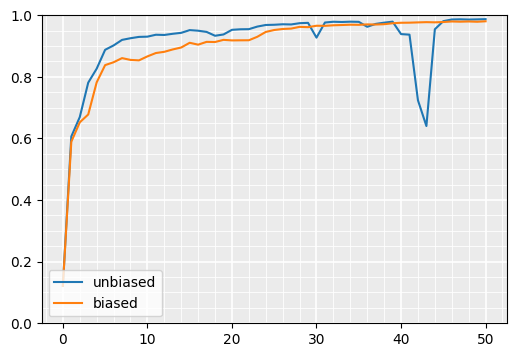

In [ ]:
fig = plt.figure(figsize=(6, 4))
xvalues = [i for i in range (50+1)]                                    
                                    
for biased in ["0", "1"]:
    yvalues = raw_results[raw_results.biased == biased]["test_accuracy"].values[0]
    
    if biased == "0":
        plt.plot(xvalues, yvalues, label="unbiased")
    elif biased == "1":
        plt.plot(xvalues, yvalues, label="biased")
    else:
        plt.plot(xvalues, yvalues, label="hybrid", linestyle="--")

ax = plt.gca()
ax.set_ylim([0, 1])
plt.legend(loc='lower left')
ax = plt.gca()
ax.set_facecolor('#EBEBEB')
ax.grid(which='major', color='white', linewidth=1.2)
ax.grid(which='minor', color='white', linewidth=0.6)
# Show the minor ticks and grid.
ax.minorticks_on()
# Now hide the minor ticks (but leave the gridlines).
ax.tick_params(which='minor', bottom=False, left=False)

# plt.grid()
plt.savefig(folder+'/'+keyword+'.png', bbox_inches='tight')
plt.show()